In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.8 MB/s eta 0:00:00


In [2]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 131.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [1]:
import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.1.14 🚀 Python-3.9.19 torch-2.1.1+cpu CPU (Intel Core(TM) i7-4790 3.60GHz)
Setup complete ✅ (8 CPUs, 15.9 GB RAM, 224.9/225.9 GB disk)


In [ ]:
from roboflow import Roboflow

# Initialize with your API Key
rf = Roboflow(api_key="oKNVtv9lLwDYmmUJUio9")

# Access the project and download the dataset version in YOLOv8 format
project = rf.workspace("for-practicing").project("cat-dog-injury-people-9im9p")
dataset = project.version(1).download("yolov8")

In [5]:
import yaml

# Load the dataset info
with open(f"{dataset.location}/data.yaml", 'r') as f:
    data_info = yaml.safe_load(f)

print(f"Classes: {data_info['names']}")
# In a real project, you would loop through the label files to count them.
# For now, look at the terminal output during training—YOLO prints a 'labels' summary!

Classes: ['cat', 'dog', 'minor injury', 'people', 'severe injury']


In [6]:
from ultralytics import YOLO

# 1. Load a pretrained YOLOv8 nano model
# Using 'yolov8n.pt' is recommended for your prototype as it is fast and efficient [cite: 123, 127]
model = YOLO('yolov8n.pt')

# 2. Train the model
# This uses the data.yaml file created during your dataset download
results = model.train(
    data=f"{dataset.location}/data.yaml", # Path to your dataset configuration [cite: 121]
    epochs=50,                           # Number of training iterations [cite: 91]
    imgsz=640,                           # Resize images to 640x640 pixels [cite: 90, 117]
    plots=True,                          # Save charts showing accuracy and loss
    name='petstress_wound_model'         # Name for this training run
)

Ultralytics 8.3.246 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cat,-dog,-injury,-people-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=petstress_wound_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe


image 1/1 /content/cat,-dog,-injury,-people-1/test/images/injured_dog_156_png.rf.047e8c98da1db7b804972052d0a9a8aa.jpg: 640x640 3 dogs, 2 peoples, 3 severe injurys, 8.1ms
Speed: 1.6ms preprocess, 8.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


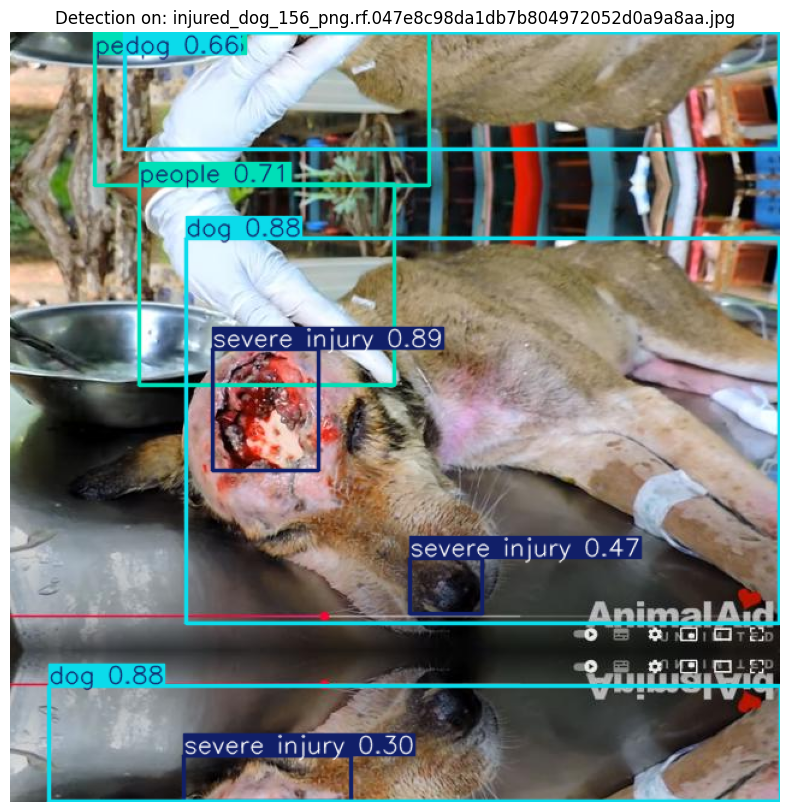

In [9]:
import os
import random
import cv2
from matplotlib import pyplot as plt
from ultralytics import YOLO

# 1. Load your best trained model
# Replace 'petstress_wound_model' if you used a different name during training
model_path = '/content/runs/detect/petstress_wound_model/weights/best.pt'
model = YOLO(model_path)

# 2. Get a list of all images in the test set
test_images_path = os.path.join(dataset.location, 'test', 'images')
test_images = [f for f in os.listdir(test_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

# 3. Select one random image
random_image_name = random.choice(test_images)
random_image_path = os.path.join(test_images_path, random_image_name)

# 4. Run detection on the selected image
results = model.predict(source=random_image_path, conf=0.25) # conf=0.25 is the sensitivity

# 5. Visualize the result
for result in results:
    # Plot the results onto the image (includes bounding boxes and labels)
    res_plotted = result.plot()

    # Convert BGR (OpenCV format) to RGB (Matplotlib format)
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(res_rgb)
    plt.title(f"Detection on: {random_image_name}")
    plt.axis('off')
    plt.show()

In [32]:
from google.colab import files
import os

# This opens a file picker to upload your downloaded image
uploaded = files.upload()

# Get the name of the file you just uploaded
uploaded_image_path = list(uploaded.keys())[0]
print(f"Uploaded file: {uploaded_image_path}")

Saving 1_dog_minor.jpg to 1_dog_minor (2).jpg
Uploaded file: 1_dog_minor (2).jpg



image 1/1 /content/1_dog_minor (2).jpg: 448x640 2 dogs, 2 minor injurys, 8.7ms
Speed: 1.5ms preprocess, 8.7ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


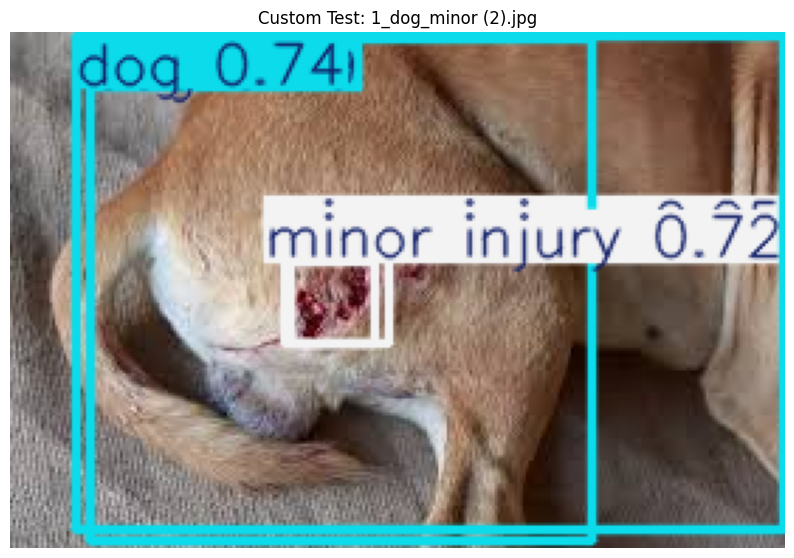

In [33]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

# 1. Load your best model
model = YOLO('/content/runs/detect/petstress_wound_model/weights/best.pt')

# 2. Run the detection
# We use the 'uploaded_image_path' from the previous step
results = model.predict(source=uploaded_image_path, conf=0.25)

# 3. Show the result
for result in results:
    res_plotted = result.plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(res_rgb)
    plt.title(f"Custom Test: {uploaded_image_path}")
    plt.axis('off')
    plt.show()

In [30]:
from google.colab import files

# This will prompt you to select the video file from your computer
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print(f"Uploaded video: {video_path}")

Saving dog_major_v3.mp4 to dog_major_v3.mp4
Uploaded video: dog_major_v3.mp4



video 1/1 (frame 1/228) /content/dog_major_v3.mp4: 384x640 (no detections), 8.1ms
video 1/1 (frame 2/228) /content/dog_major_v3.mp4: 384x640 (no detections), 5.6ms
video 1/1 (frame 3/228) /content/dog_major_v3.mp4: 384x640 (no detections), 6.2ms
video 1/1 (frame 4/228) /content/dog_major_v3.mp4: 384x640 (no detections), 5.6ms
video 1/1 (frame 5/228) /content/dog_major_v3.mp4: 384x640 (no detections), 5.5ms
video 1/1 (frame 6/228) /content/dog_major_v3.mp4: 384x640 (no detections), 5.5ms
video 1/1 (frame 7/228) /content/dog_major_v3.mp4: 384x640 (no detections), 7.0ms
video 1/1 (frame 8/228) /content/dog_major_v3.mp4: 384x640 1 people, 5.6ms
video 1/1 (frame 9/228) /content/dog_major_v3.mp4: 384x640 (no detections), 5.5ms
video 1/1 (frame 10/228) /content/dog_major_v3.mp4: 384x640 (no detections), 5.5ms
video 1/1 (frame 11/228) /content/dog_major_v3.mp4: 384x640 (no detections), 6.9ms
video 1/1 (frame 12/228) /content/dog_major_v3.mp4: 384x640 1 people, 1 severe injury, 5.5ms
video 1/1

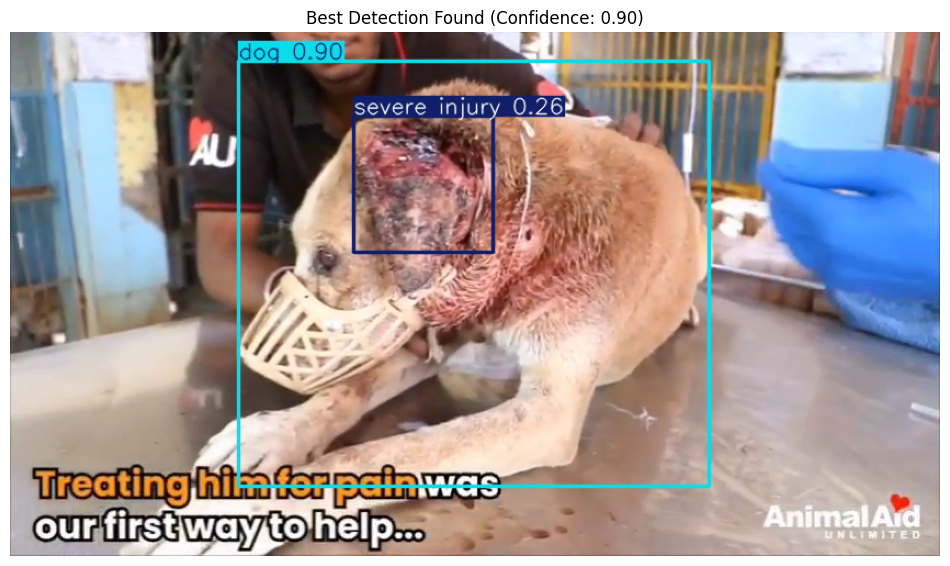

In [31]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

# 1. Load your trained model
model = YOLO('/content/runs/detect/petstress_wound_model/weights/best.pt')

# 2. Run inference on the video
# We don't use save=True because we only want to show one frame
results = model.predict(source=video_path, stream=True, conf=0.25)

best_frame = None
max_conf = 0.0

# 3. Iterate through frames to find the highest confidence
for result in results:
    if len(result.boxes) > 0:
        # Get the highest confidence score in the current frame
        current_max = result.boxes.conf.max().item()

        # If this frame is better than our previous best, save it
        if current_max > max_conf:
            max_conf = current_max
            best_frame = result.plot() # Plot boxes on the best frame

# 4. Display the best frame found
if best_frame is not None:
    # Convert BGR (OpenCV) to RGB (Matplotlib)
    res_rgb = cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 12))
    plt.imshow(res_rgb)
    plt.title(f"Best Detection Found (Confidence: {max_conf:.2f})")
    plt.axis('off')
    plt.show()
else:
    print("No wounds detected in this video.")